## DATA CLEANING / FEATURE ENGINEERING / EDA 

In [13]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import sys
from IPython.display import display

# Add project root to python's module search path
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT)) 

# Graphs Config
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Import cleaning pipeline
from src.preprocessing.preprocessing_pipeline import run_preprocessing_pipeline

raw_data_path = Path("../data/raw/raw_data.csv")

# Run cleaning pipeline
df_clean = run_preprocessing_pipeline(raw_data_path)
print()

print("Cleaned Data:")
display(df_clean.head())

print("Cleaned Data information about dtypes and missing values:")
print(df_clean.info())

df_clean.to_csv("../data/processed/cleaned_data.csv", index=False, encoding="utf-8")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Removed Duplicates 0

Cleaned Data:


,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn,tenure_group,total_services_count,avg_monthly_spend_ratio
0,7590-VHVEG,Female,0.0,Yes,No,1.0,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-12_months,1,1.000000
1,5575-GNVDE,Male,0.0,No,No,34.0,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,0,25-48_months,3,0.975830
2,3668-QPYBK,Male,0.0,No,No,2.0,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-12_months,3,1.004178
3,7795-CFOCW,Male,0.0,No,No,45.0,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,25-48_months,3,0.967034
4,9237-HQITU,Female,0.0,No,No,2.0,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-12_months,1,1.072489


Cleaned Data information about dtypes and missing values:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   customer_id              7043 non-null   str     
 1   gender                   7043 non-null   str     
 2   senior_citizen           7043 non-null   float64 
 3   partner                  7043 non-null   str     
 4   dependents               7043 non-null   str     
 5   tenure                   7043 non-null   float64 
 6   phone_service            7043 non-null   str     
 7   multiple_lines           7043 non-null   str     
 8   internet_service         7043 non-null   str     
 9   online_security          7043 non-null   str     
 10  online_backup            7043 non-null   str     
 11  device_protection        7043 non-null   str     
 12  tech_support             7043 non-null   str     
 13  streaming_t_v   

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
monthly_charges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
total_charges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80


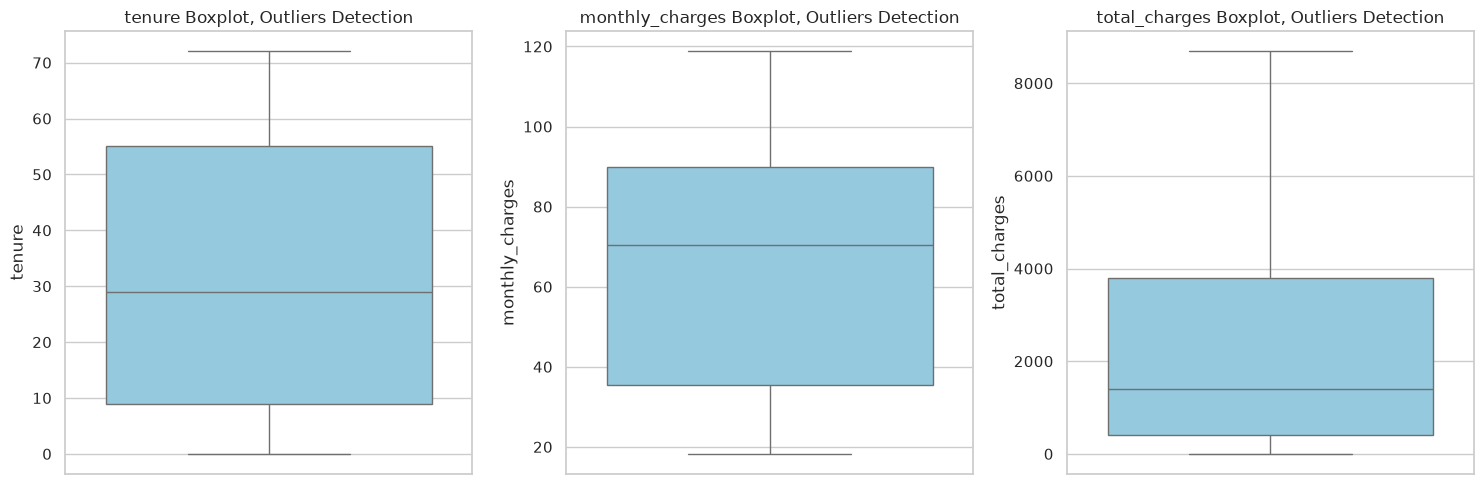

In [14]:
# Univariate Analysis & Detecting Outliers

# Continuous numerical values
num_cols = ["tenure", "monthly_charges", "total_charges"]

# Basic descriptive statistics
display(df_clean[num_cols].describe().T)

# Outliers and distribution visualization
plt.figure(figsize=(15, 5))

for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df_clean[col], color="skyblue")
    plt.title(f"{col} Boxplot, Outliers Detection")
plt.tight_layout()

# Saving figure into artifacts folder
Path("../artifacts/figures/distributions").mkdir(parents=True, exist_ok=True)
plt.savefig("../artifacts/figures/distributions/outliers_boxplots.png")
plt.show()

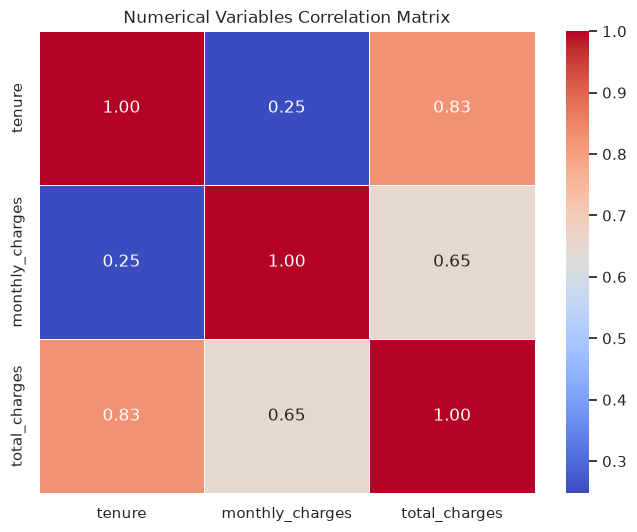

In [15]:
plt.figure(figsize=(8, 6))
corr_matrix = df_clean[num_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Numerical Variables Correlation Matrix")

# Saving figure into artifacts folder
Path("../artifacts/figures/correlations").mkdir(parents=True, exist_ok=True)
plt.savefig("../artifacts/figures/correlations/correlation_matrix.png")
plt.show()

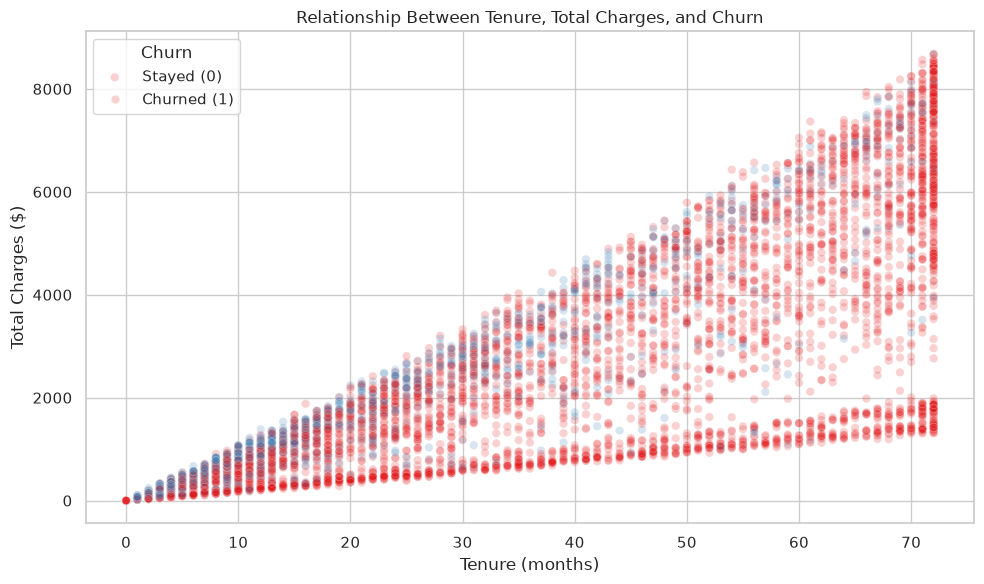

In [16]:
# Bivariate Analysis: Scatter Plot (Tenure vs Total Charges, colored by Churn)
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="tenure",
    y="total_charges",
    hue="churn",
    palette="Set1",
    alpha=0.2,
)

plt.title("Relationship Between Tenure, Total Charges, and Churn")
plt.xlabel("Tenure (months)")
plt.ylabel("Total Charges ($)")
plt.legend(title="Churn", labels=["Stayed (0)", "Churned (1)"])
plt.tight_layout()

# Save the figure in the artifacts folder
Path("../artifacts/figures/distributions").mkdir(parents=True, exist_ok=True)

plt.savefig("../artifacts/figures/distributions/scatter_tenure_charges_churn.png")
plt.show()

,contract,churn
0,Month-to-month,0.427097
1,One year,0.112695
2,Two year,0.028319


/tmp/ipykernel_525555/3056489463.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=contract_churn, x="contract", y="churn", palette="Blues_d")


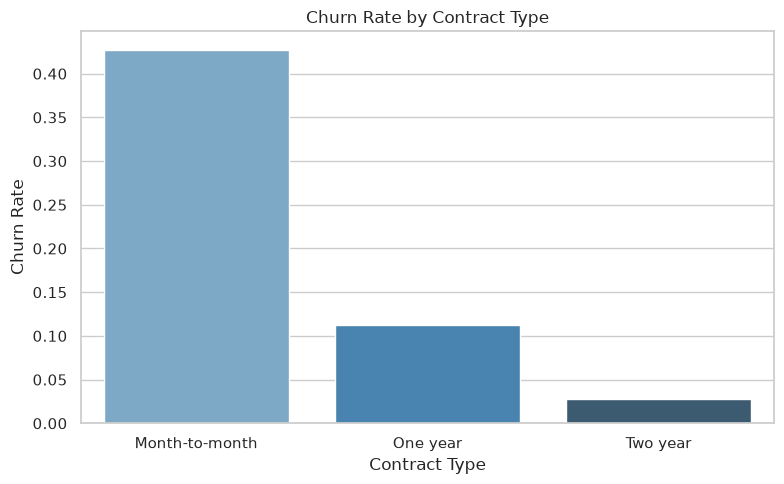

In [17]:
# Categorical Analysis (Contract type vs Churn rate)

plt.figure(figsize=(8, 5))
contract_churn = df_clean.groupby("contract")["churn"].mean().reset_index()

display(contract_churn)

sns.barplot(data=contract_churn, x="contract", y="churn", palette="Blues_d")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate")
plt.tight_layout()

# Save the figure in the artifacts folder
Path("../artifacts/figures/distributions").mkdir(parents=True, exist_ok=True)
plt.savefig("../artifacts/figures/distributions/contract_churn_rate.png")
plt.show()

## Step 1 Summary: Data Cleaning, Imputation, Feature Engineering & EDA

In this step, we built a robust, production-ready preprocessing and exploratory data analysis workflow:
1. **Structural Cleaning:** Standardized column names to `snake_case`, stripped trailing whitespaces, and handled corrupted/sentinel values (such as converting whitespace strings in `total_charges` to true `NaN`s).
2. **Target Encoding:** Converted the `churn` target column into a clean binary numeric format (`0` and `1`).
3. **Advanced Imputation:** Implemented `KNNImputer` to intelligently fill missing values based on neighboring customer profiles, preserving the underlying MAR (Missing At Random) data distribution.
4. **Feature Engineering:** Created derived features to boost model predictive power:
   - `tenure_group`: Customer lifecycle cohorts.
   - `total_services_count`: Total active add-on services to measure platform stickiness.
   - `avg_monthly_spend_ratio`: Spending consistency indicator.
5. **Exploratory Data Analysis (EDA):** Inspected numerical distributions, boxplots for outlier detection, correlation matrices, and categorical churn drivers (revealing that month-to-month contracts exhibit significantly higher churn rates compared to long-term commitments). All artifacts have been successfully generated and saved under `artifacts/figures/`.